In [24]:
import numpy as np
import matplotlib.pyplot as plt
import lmfit
from plottr.data.datadict_storage import datadict_from_hdf5

def S11_magnon_model(freq, fc, fm, ke, ki, gamma, g, a0, a1, Poff,ed):
    numer = (1j*(freq-fc)+(ke-ki)/2)*(1j*(freq-fm)-gamma/2) + (g**2)
    denom = (1j*(freq-fc)-(ke+ki)/2)*(1j*(freq-fm)-gamma/2) + (g**2)
    model = (numer/denom * (a0+a1*(freq-freq[0])) * np.exp(1j*(Poff-ed*2*np.pi*freq)))
    return model

In [3]:
datadict = datadict_from_hdf5(r"S:\K_Sunada\result\CDY150\2023-10-24\2023-10-24T113124_6d2c738b-td_spectrum\data.ddh5")
datadict

s11: (101,)
  ⌙ frequency (Hz): (101,)

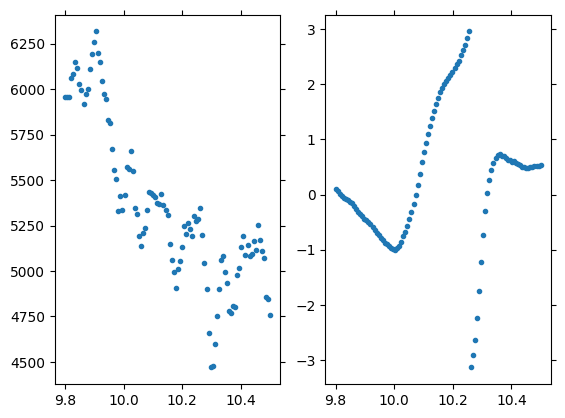

In [5]:
s11 = datadict['s11']['values']
freq = datadict['frequency']['values'] * 1e-9
fig,ax = plt.subplots(1,2)
ax[0].plot(freq,np.abs(s11))
ax[1].plot(freq,np.angle(s11))

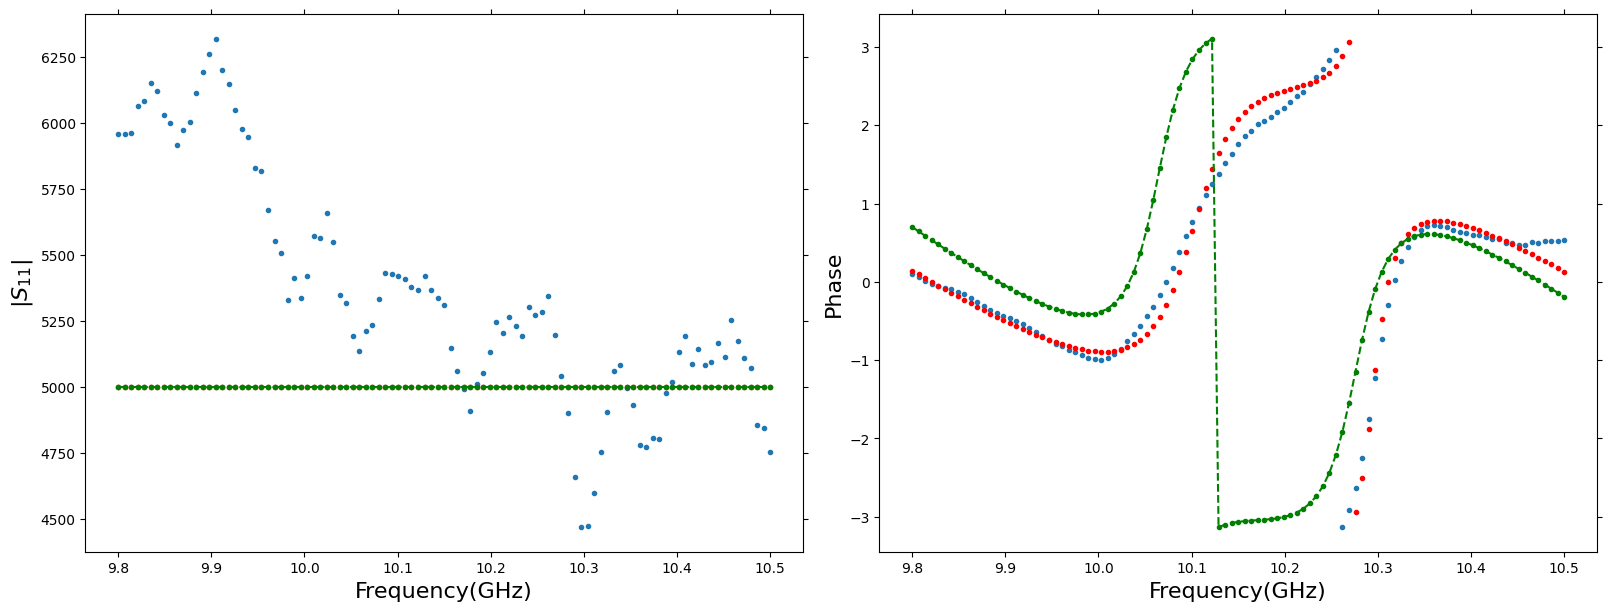

In [41]:
par_ini = {'fc': 10.17,  'fm': 10.17,    'ke': 120e-3,   'ki': 0,  'g': 110e-3, 'gamma': 0,
           'a0': 5000,  'a1': 0,        'Poff': 33.7,   'ed': 1.46}
par_min = {'fc': 0,     'fm': 0,        'ke': 0,        'ki': 0,        'g': 0,     'gamma': 0,
           'a0': 0,     'a1': -np.inf,  'Poff': -np.inf,'ed': -np.inf}
par_max = {'fc': np.inf,'fm': np.inf,   'ke': np.inf,   'ki': np.inf,   'g': np.inf,'gamma': np.inf,
           'a0': np.inf,'a1': np.inf,   'Poff': np.inf, 'ed': np.inf}
par_var = {'fc': True, 'fm': True,    'ke': False,    'ki': False,    'g': True, 'gamma': False,
           'a0': False, 'a1': False,    'Poff': True,  'ed': True}

model=lmfit.Model(S11_magnon_model)
params = model.make_params()

for name in list(par_ini):
    params[name].set(value=par_ini[name])
    
for name in list(par_min):
    params[name].set(min=par_min[name])
    
for name in list(par_max):
    params[name].set(max=par_max[name])
    
for name in list(par_var):
    params[name].set(vary=par_var[name])

result = model.fit(freq=freq, data=s11, params=params, method='leastsq')

fig, ax = plt.subplots(1,2,figsize=(16,6),constrained_layout=True)
ax[0].set_xlabel('Frequency(GHz)',fontsize=16)
ax[0].set_ylabel(r'$|S_{11}|$', fontsize=16)
ax[1].set_xlabel('Frequency(GHz)',fontsize=16)
ax[1].set_ylabel('Phase', fontsize=16)
# ax.tick_params(direction='in')

ax[0].plot(freq,np.abs(s11), ls='', marker='.')
ax[0].plot(freq,np.abs(result.best_fit), color='red')
ax[0].plot(freq,np.abs(result.init_fit), color='green', ls='--', marker='')
ax[1].plot(freq,np.angle(s11), ls='', marker='.')
ax[1].plot(freq,np.angle(result.best_fit), color='red')
ax[1].plot(freq,np.angle(result.init_fit), color='green', ls='--', )
# ax[1][0].plot(freq,np.abs(s11) - np.abs(result.best_fit), ls='', marker='.')
# error_phi = np.angle(s11) - np.angle(result.best_fit)
# error_phi[error_phi>np.pi] -= 2*np.pi
# error_phi[error_phi<-np.pi] += 2*np.pi
# ax[1][1].plot(freq,error_phi, ls='', marker='.')

result